# Data Visualization

A quick exploratory look at the training data: missing values, categorical distributions, and numerical distributions.

The notebook is divided into four parts:

0. Setup the work environment.
1. Visualize the full training set.
2. Visualize the training data for addicted users.
3. Visualize the training data for non-addicted users.

## 0. Setup

### Libraries

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

### Load data

In [2]:
df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
df_train = df_train.drop("id", axis=1)

df_train.head(10)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


### Plotting helpers

Three functions are used for the plots in this notebook:
- `plot_missing_values` — horizontal bar chart of % missing per column
- `plot_categorical_distributions` — count + % bar chart per categorical column
- `plot_numerical_distributions` — histogram per numerical column, with
  binning/ticks adapted to whether a column is a float, a small-range
  integer, or a large-range integer

The functions take a `DataFrame` as input, so they can be reused for different subsets of the data

In [3]:
def plot_missing_values(df, figsize_width=9, row_height=0.35):
    """Horizontal bar chart of the percentage of missing values per column
    (columns with zero missing values are skipped)."""
    missing_pct = (
        df.isna()
        .mean()
        .mul(100)
        .loc[lambda x: x > 0]
        .sort_values()
    )

    if missing_pct.empty:
        print("No missing values found.")
        return None

    fig, ax = plt.subplots(
        figsize=(figsize_width, max(4, len(missing_pct) * row_height))
    )

    ax.barh(missing_pct.index, missing_pct)

    for i, pct in enumerate(missing_pct):
        ax.text(pct + 0.5, i, f"{pct:.1f}%", va="center")

    ax.set_xlim(0, max(5, missing_pct.max() * 1.12))
    ax.set_xlabel("Missing values (%)")
    ax.set_title("Missing Values by Column", loc="left", fontweight="bold")

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()
    return fig

In [4]:
def plot_categorical_distributions(df, cols, n_cols=2, subplot_height=4.5):
    """Grid of bar charts (count + % label) for each categorical column."""
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, subplot_height * n_rows))
    axes = np.atleast_1d(axes).flatten()
    colors = plt.cm.tab10.colors

    for ax, col in zip(axes, cols):
        counts = df[col].value_counts()
        pct = counts / counts.sum() * 100
        x = np.arange(len(counts))

        ax.bar(x, counts.values, color=[colors[i % len(colors)] for i in x])

        for xi, (count, p) in enumerate(zip(counts.values, pct.values)):
            ax.text(xi, count * 1.02, f"{p:.1f}%", ha="center", va="bottom")

        ax.set_xticks(x)
        ax.set_xticklabels(counts.index, rotation=30, ha="right")
        ax.set_title(col.replace("_", " ").title())
        ax.set_ylabel("Count")
        ax.margins(y=0.12)

    for ax in axes[len(cols):]:
        ax.remove()

    plt.tight_layout()
    plt.show()
    return fig

In [5]:
def plot_numerical_distributions(
    df,
    float_cols=None,
    low_range_integer_cols=None,
    high_range_integer_cols=None,
    n_cols=3,
    subplot_height=4,
):
    """Grid of histograms for numerical columns.

    - `low_range_integer_cols` get one bin per integer value
    - `high_range_integer_cols` get 30 bins with an integer-only tick locator
    - `float_cols` get 30 bins with a plain tick locator
    """
    float_cols = float_cols or []
    low_range_integer_cols = low_range_integer_cols or []
    high_range_integer_cols = high_range_integer_cols or []
    cols = float_cols + low_range_integer_cols + high_range_integer_cols

    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, subplot_height * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, cols):
        data = df[col].dropna()

        if col in low_range_integer_cols:
            value_min, value_max = int(data.min()), int(data.max())
            bins = np.arange(value_min - 0.5, value_max + 1.5, 1)
            ax.hist(data, bins=bins, color="steelblue", edgecolor="black", linewidth=0.7)
            ax.set_xticks(np.arange(value_min, value_max + 1))
        else:
            ax.hist(data, bins=30, color="steelblue", edgecolor="black", linewidth=0.7)
            is_high_range = col in high_range_integer_cols
            ax.xaxis.set_major_locator(
                MaxNLocator(nbins=10 if is_high_range else 8, integer=is_high_range)
            )

        ax.set_title(col.replace("_", " ").title())
        ax.set_ylabel("Count")

    for ax in axes[len(cols):]:
        ax.remove()

    plt.tight_layout()
    plt.show()
    return fig

### Column groups

Columns are grouped by how they should be plotted rather than by dtype.

In [6]:
target_col = "addicted_label"  # Kept separate to avoid plotting it when filtering by target

categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact",
]

float_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "weekend_screen_time",
]

low_range_integer_cols = ["age"]

high_range_integer_cols = [
    "notifications_per_day",
    "app_opens_per_day",
]

## 1. Full training set

Visualize the full training set to establish a baseline for comparison with
the target-conditioned sections.

### Numerical summary

In [7]:
df_train.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


### Missing values

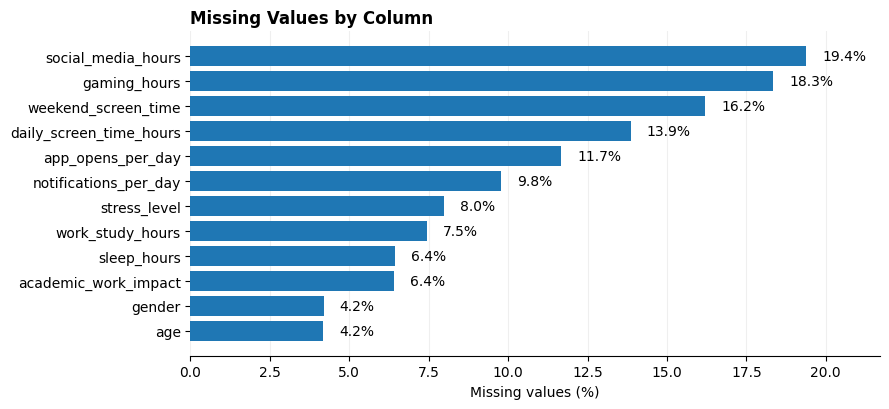

In [8]:
plot_missing_values(df_train);

### Categorical distributions

Distribution of the categorical features, including the target.

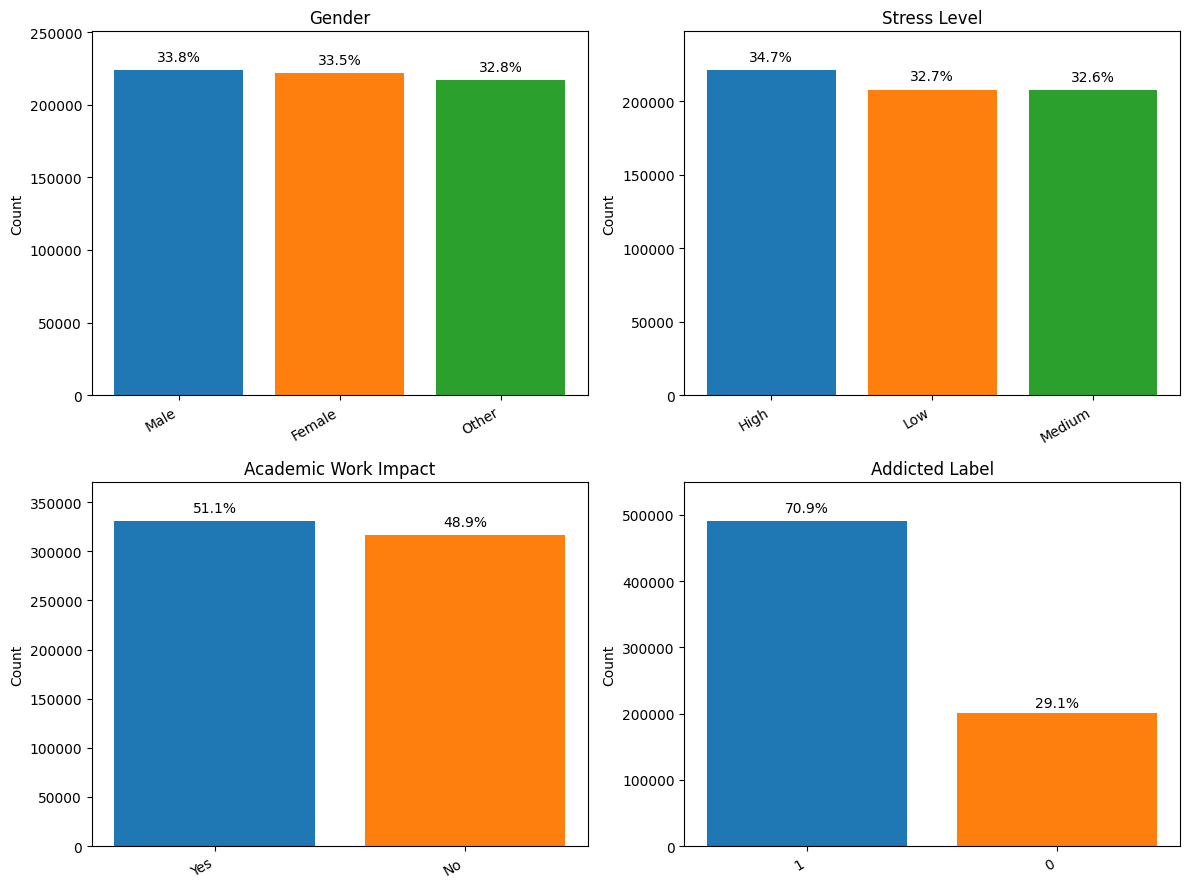

In [9]:
plot_categorical_distributions(df_train, categorical_cols+[target_col]);

### Numerical distributions

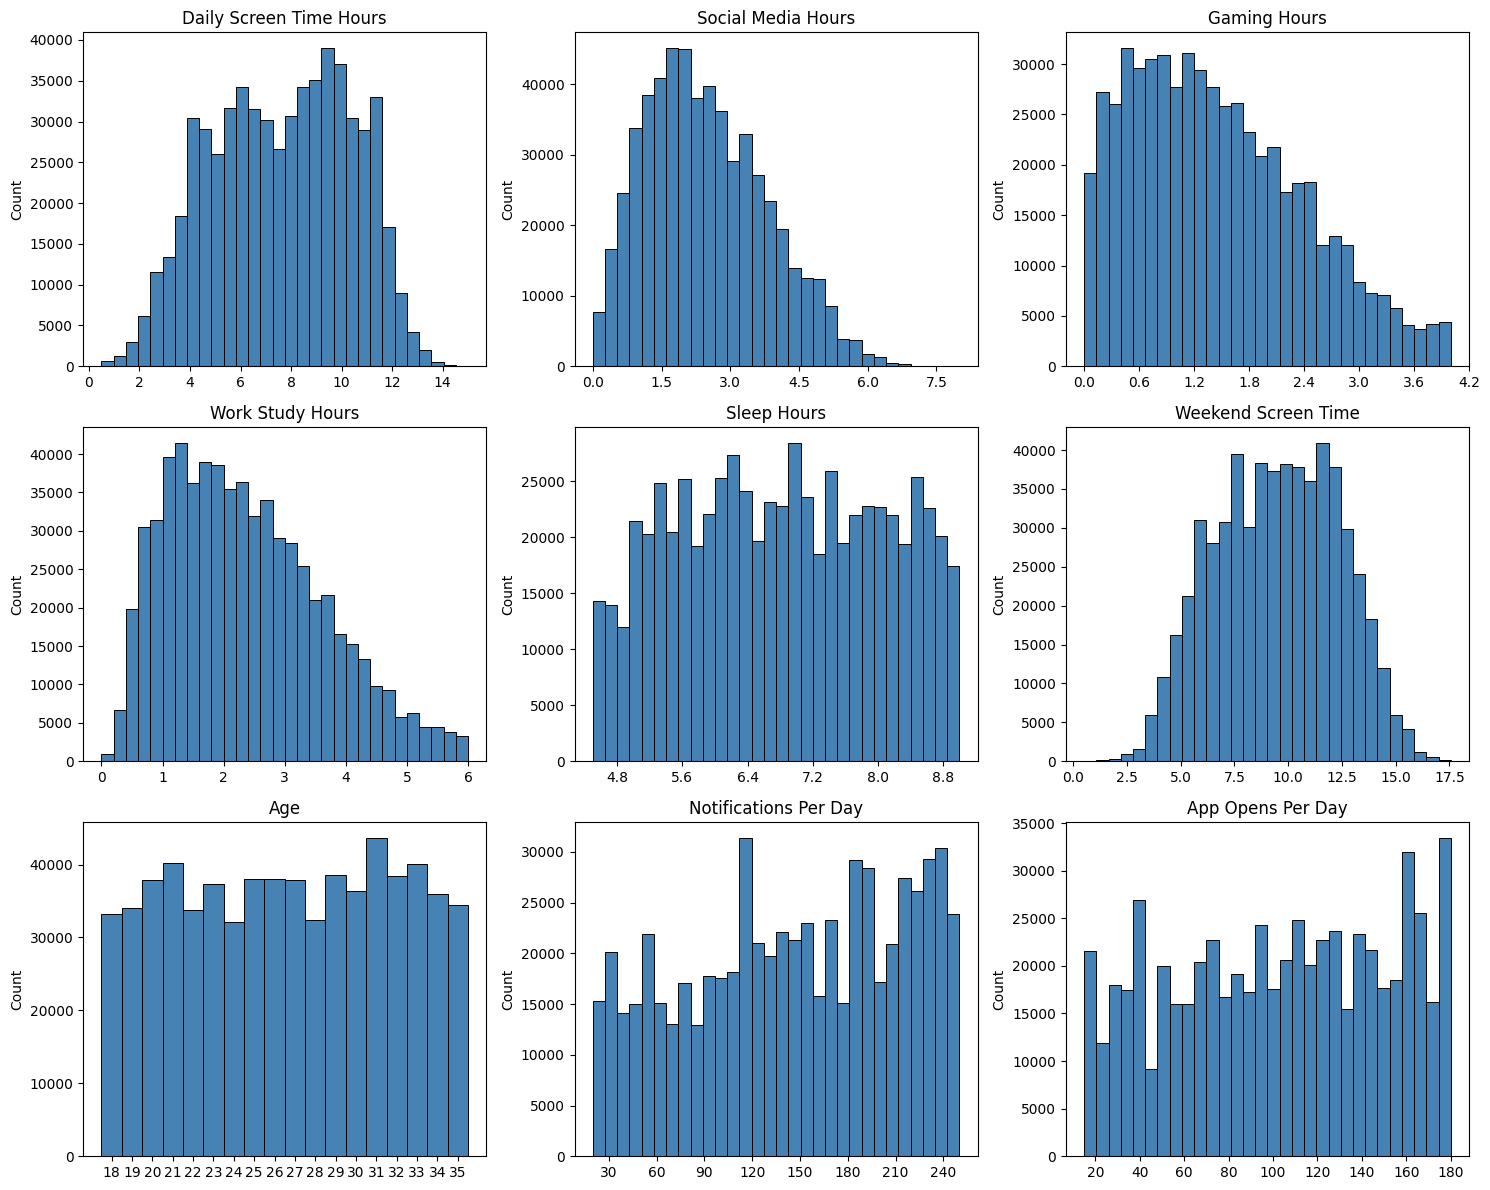

In [10]:
plot_numerical_distributions(
    df_train,
    float_cols=float_cols,
    low_range_integer_cols=low_range_integer_cols,
    high_range_integer_cols=high_range_integer_cols,
);

## 2. Target = 1 (Addicted)

Visualize the training data for rows where `addicted_label == 1`.

### Numerical summary

In [11]:
df_pos = df_train[df_train["addicted_label"] == 1]
df_pos.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,469836.000000,422293.000000,395416.000000,400367.000000,453863.000000,458743.000000,442473.000000,432945.000000,410836.000000,490474.0
mean,26.628749,8.706523,2.919495,1.582119,2.569566,6.837970,145.406142,104.592844,10.558729,1.0
std,5.113040,2.337327,1.235099,0.978345,1.306253,1.230772,65.885794,48.246055,2.496676,0.0
min,18.000000,0.500000,0.010000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,1.0
25%,22.000000,7.210000,1.980000,0.760000,1.510000,5.830000,93.000000,64.000000,8.930000,1.0
50%,27.000000,9.070000,2.820000,1.480000,2.470000,6.840000,150.000000,109.000000,10.790000,1.0
75%,31.000000,10.460000,3.760000,2.300000,3.480000,7.910000,203.000000,147.000000,12.310000,1.0
max,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.0


### Missing values

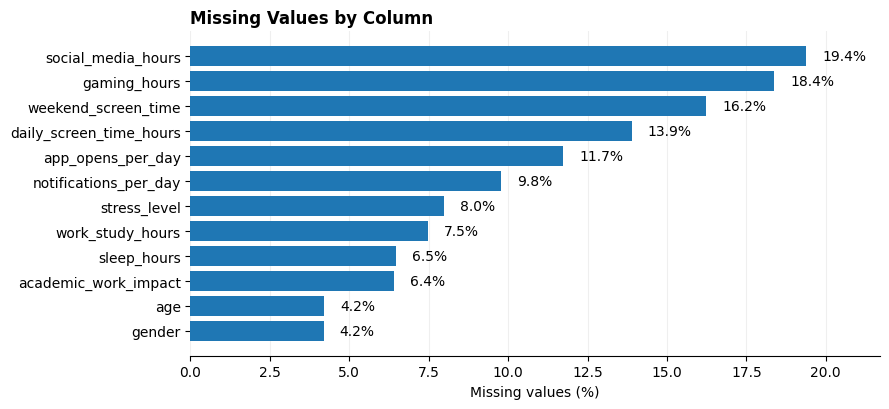

In [12]:
plot_missing_values(df_pos);

### Categorical distributions

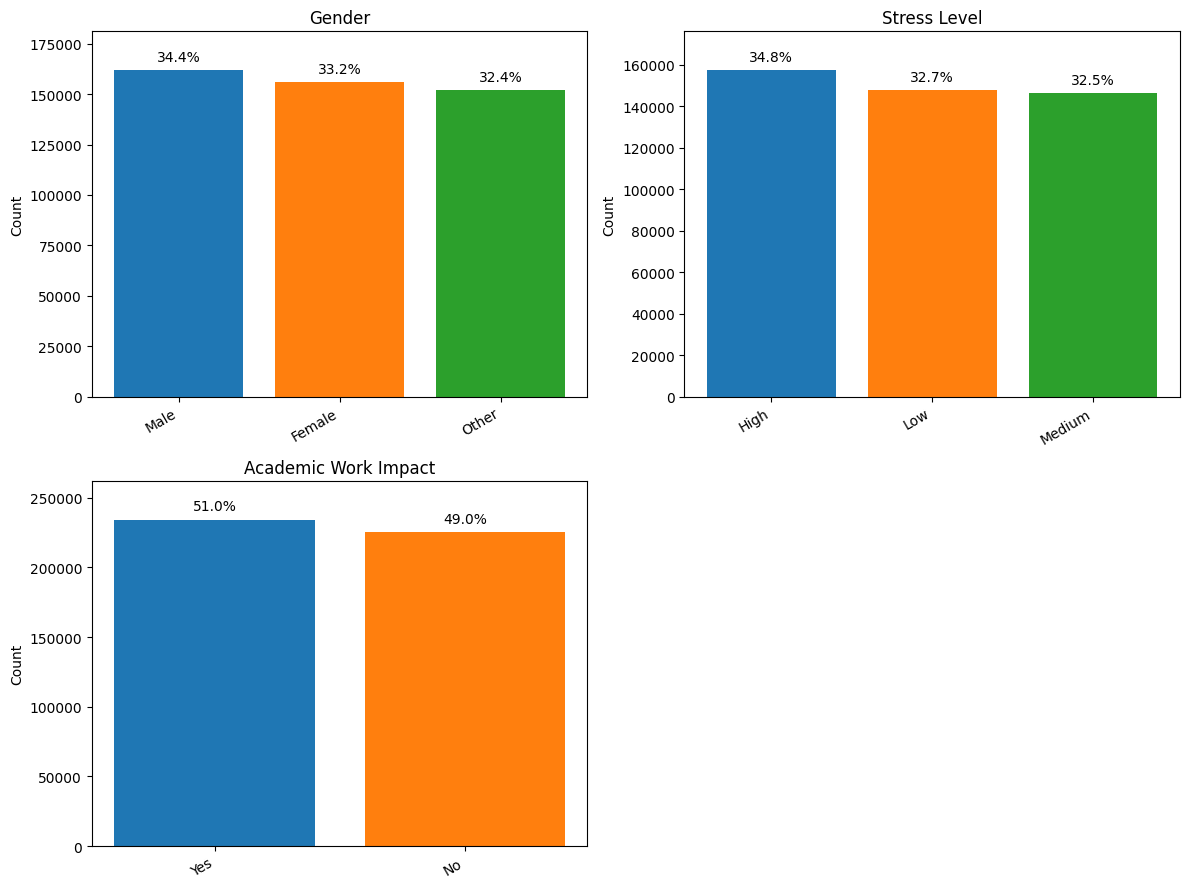

In [13]:
plot_categorical_distributions(df_pos, categorical_cols);

### Numerical distributions

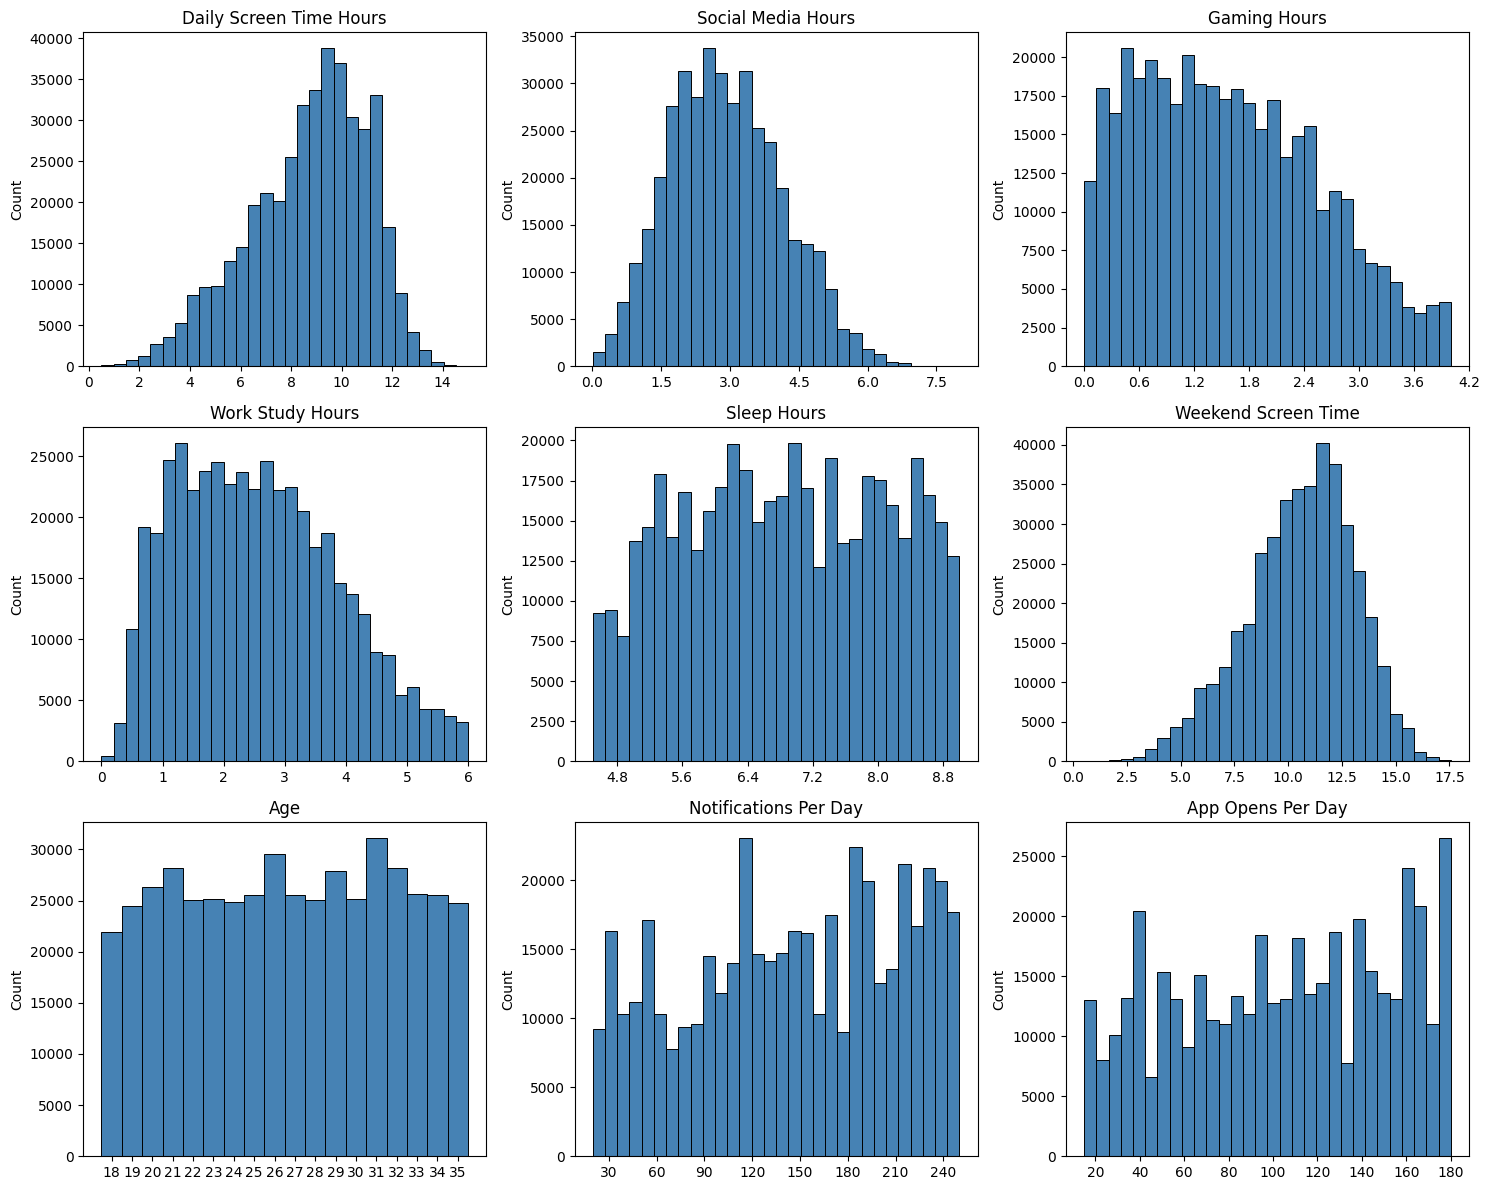

In [14]:
plot_numerical_distributions(
    df_pos,
    float_cols=float_cols,
    low_range_integer_cols=low_range_integer_cols,
    high_range_integer_cols=high_range_integer_cols,
);

## 3. Target = 0 (Not addicted)

Visualize the training data for rows where `addicted_label == 0`.

In [15]:
df_neg = df_train[df_train["addicted_label"] == 0]
df_neg.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,192604.000000,173222.000000,161958.000000,164181.000000,185988.000000,188146.000000,181312.000000,177714.000000,168470.000000,200895.0
mean,26.582864,5.042929,1.376144,1.159677,1.872582,6.722321,147.087661,97.871440,6.848920,0.0
std,5.249620,1.620399,0.739717,0.736580,0.971055,1.239769,65.979989,47.384791,1.756948,0.0
min,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.0
25%,22.000000,3.960000,0.830000,0.580000,1.130000,5.660000,93.000000,62.000000,5.620000,0.0
50%,27.000000,5.040000,1.290000,1.070000,1.750000,6.720000,154.000000,99.000000,6.820000,0.0
75%,31.000000,6.160000,1.830000,1.610000,2.470000,7.740000,206.000000,135.000000,8.050000,0.0
max,35.000000,13.320000,5.490000,4.000000,6.000000,9.000000,250.000000,180.000000,15.240000,0.0


### Missing values

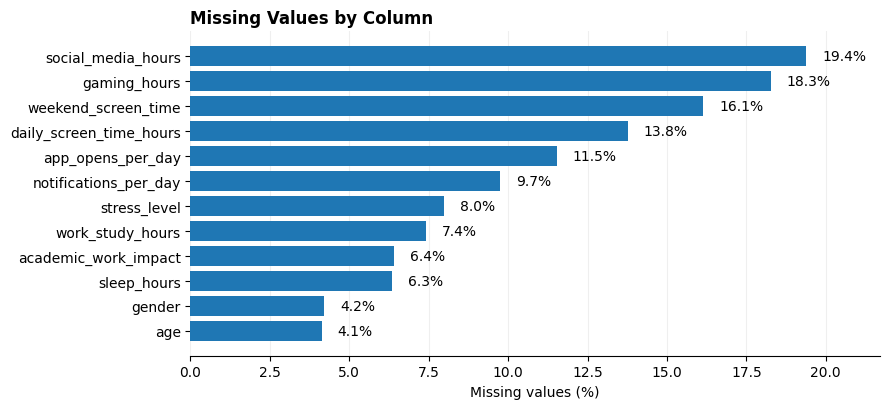

In [16]:
plot_missing_values(df_neg);

### Categorical distributions

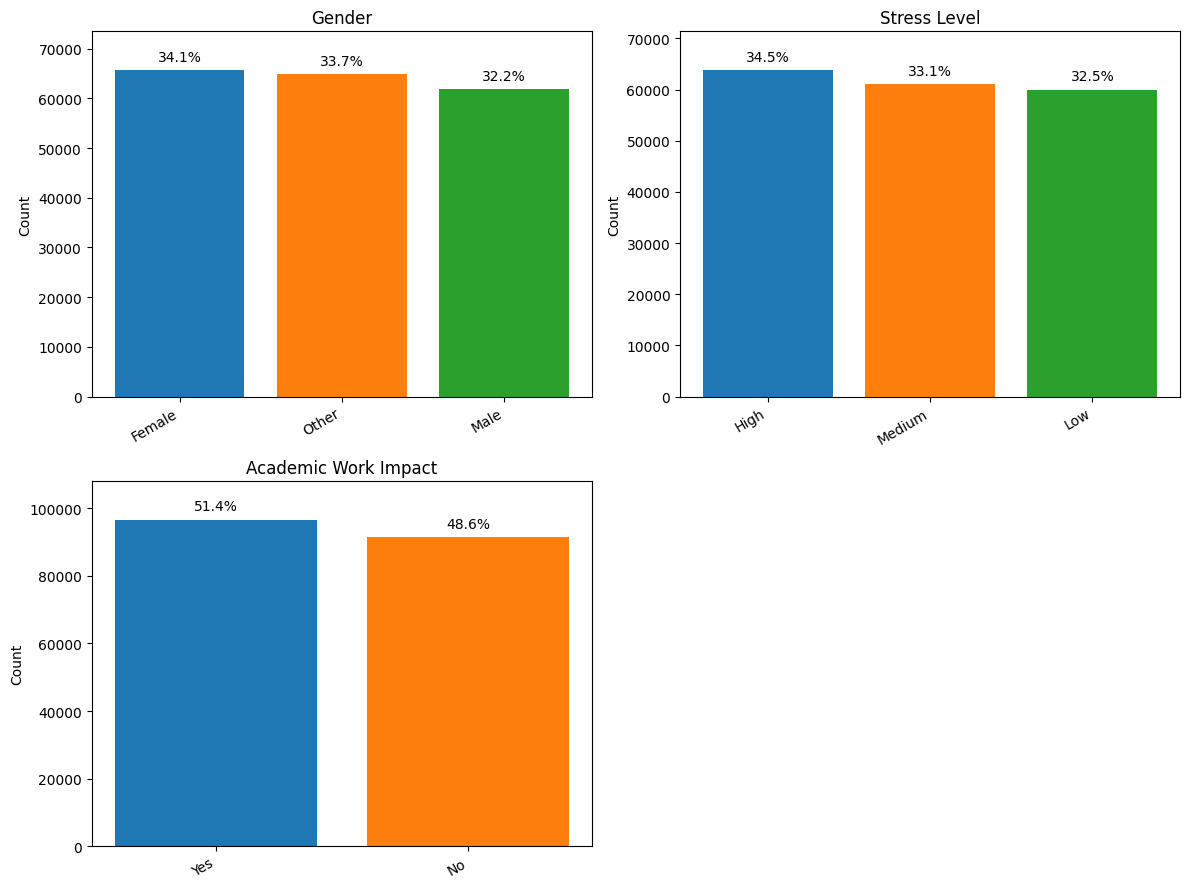

In [17]:
plot_categorical_distributions(df_neg, categorical_cols);

### Numerical distributions

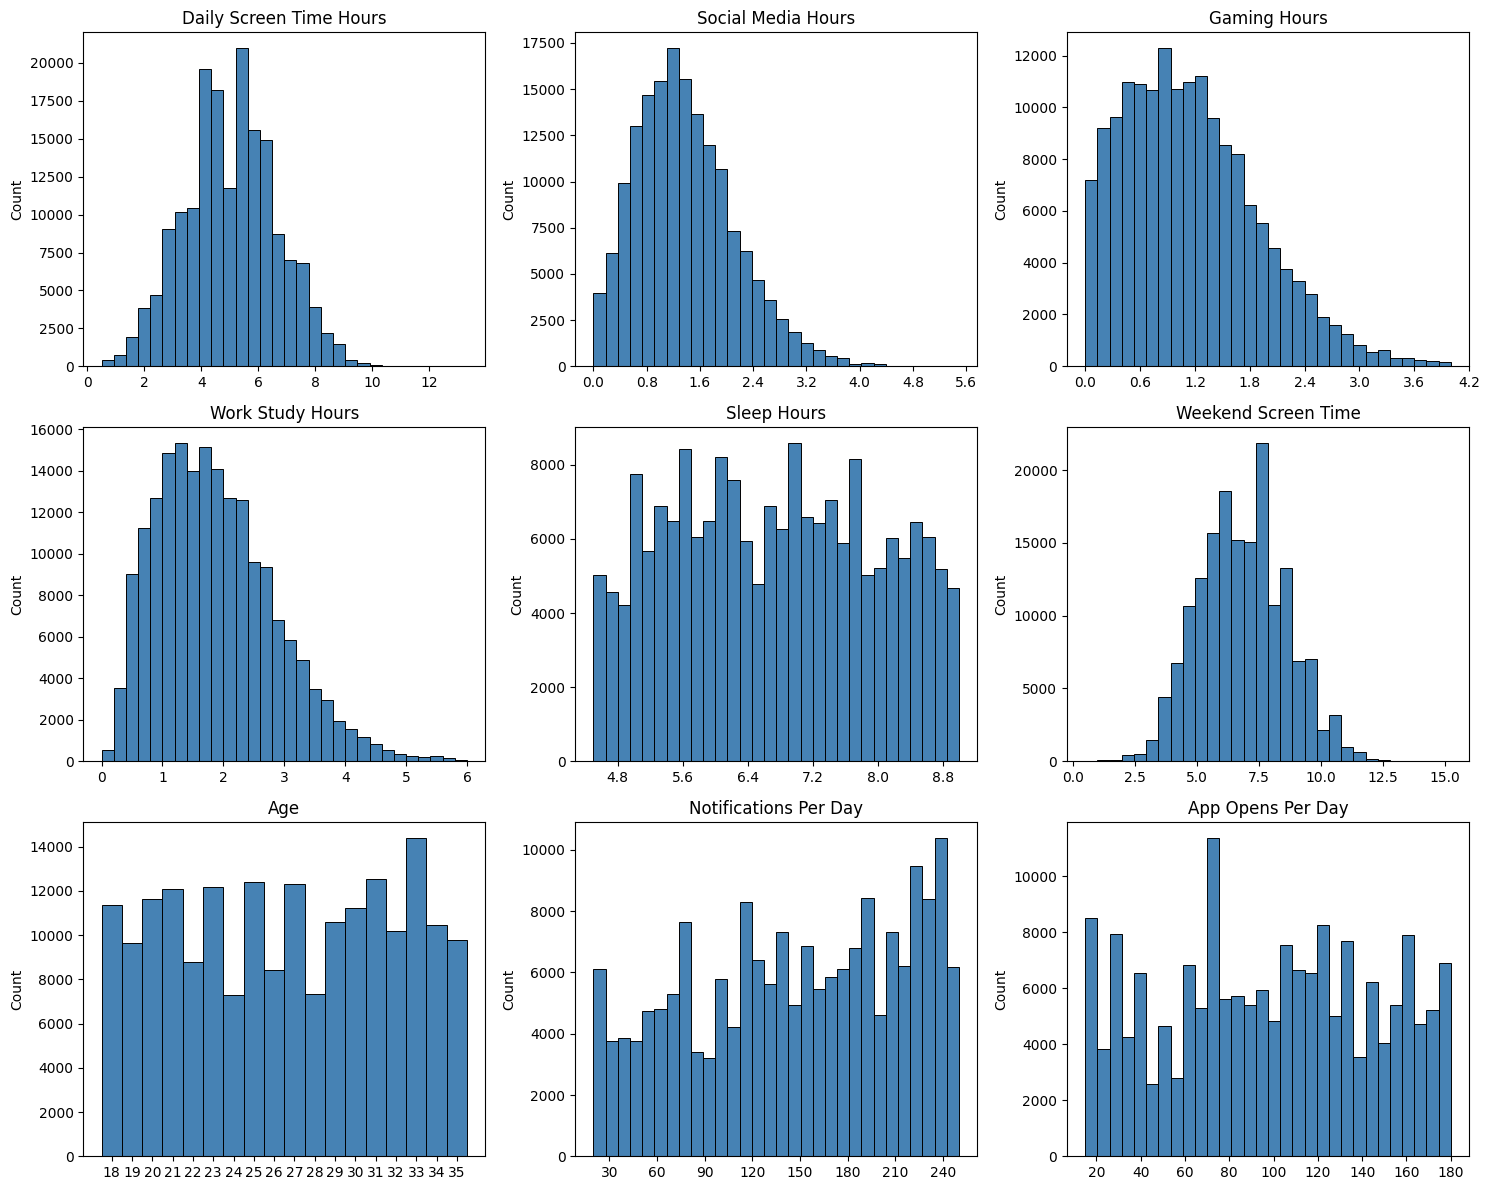

In [18]:
plot_numerical_distributions(
    df_neg,
    float_cols=float_cols,
    low_range_integer_cols=low_range_integer_cols,
    high_range_integer_cols=high_range_integer_cols,
);